# 05 — Modelling

Notebook ini melatih model **LightGBM Regressor** sebagai model utama dan membandingkannya dengan dua baseline sederhana.

## Input
- `data/processed/X_train.csv`, `X_test.csv` — fitur train/test (98 kolom, 837.697 / 209.438 baris)
- `data/processed/y_train.csv`, `y_test.csv` — target AQI
- `data/processed/df_train_datetime.csv`, `df_test_datetime.csv` — timestamp

## Output
- `models/lightgbm_model.pkl` — model LightGBM terlatih (best_iteration=308)
- `results/metrics_comparison.csv` — perbandingan metrik semua model
- `results/plots/` — plot prediksi dan perbandingan metrik

## Model yang Dilatih
1. **Baseline Naive** — prediksi = nilai AQI jam sebelumnya (`aqi_lag1`)
2. **Baseline Rolling Mean** — rata-rata 24 jam terakhir (`aqi_roll24m`)
3. **LightGBM Regressor** — model utama, early stopping pada validation set 10%

**Prasyarat:** Jalankan `04_preprocessing.ipynb` terlebih dahulu.
**Notebook berikutnya:** `06_model_evaluation.ipynb`

### 8.1 Inisialisasi & Fungsi Utility Plot

In [1]:
# === SEL INISIALISASI ===
import sys
sys.path.insert(0, '..')   # tambahkan project root agar src/ dapat diimpor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, joblib

from src.utils import evaluate_model, log_experiment   # gunakan fungsi dari src/

os.makedirs('results/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train_scaled = pd.read_csv('data/processed/X_train.csv')
X_test_scaled  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()
df_train = pd.read_csv('data/processed/df_train_datetime.csv', parse_dates=['datetime'])
df_test  = pd.read_csv('data/processed/df_test_datetime.csv',  parse_dates=['datetime'])

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")

X_train: (837697, 98), X_test: (209438, 98)


In [2]:
# evaluate() → gunakan evaluate_model dari src.utils (sudah diimpor di atas)
# Alias agar call-site di bawah tidak perlu diubah
evaluate = evaluate_model


def plot_predictions(dates, y_true, y_pred, model_name):
    """Plot versi lokal yang kompatibel dengan tampilan inline Jupyter.

    src.utils.plot_predictions memanggil plt.close() untuk penggunaan non-interaktif,
    yang mencegah tampilan inline. Versi ini memanggil plt.show() sebagai gantinya.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    dates  = np.array(dates)
    n = min(500, len(y_true))
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    axes[0].plot(dates[:n], y_true[:n], label='Aktual', alpha=0.7)
    axes[0].plot(dates[:n], y_pred[:n], label='Prediksi', alpha=0.7)
    axes[0].set_title(f'{model_name} - Prediksi vs Aktual')
    axes[0].legend()
    axes[1].scatter(y_true, y_pred, alpha=0.3, s=5)
    axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[1].set_xlabel('Aktual')
    axes[1].set_ylabel('Prediksi')
    axes[1].set_title(f'{model_name} - Scatter Aktual vs Prediksi')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'results/plots/{fname}_prediction.png', dpi=120)
    plt.show()
    print(f'Plot disimpan ke results/plots/{fname}_prediction.png')

### 8.2 Baseline Model

Sebagai referensi bawah, kita gunakan dua prediksi sederhana:
- **Naive**: prediksi = nilai AQI jam sebelumnya (`aqi_lag1`)
- **Rolling Mean**: rata-rata 24 jam terakhir dari data training (kolom `aqi_roll24m`)

In [3]:
# Baseline Naive
# Karena data time series gabungan dari banyak kota, naive prediction untuk setiap baris
# adalah nilai AQI jam sebelumnya dari kota yang sama, yang sudah disimpan di kolom 'aqi_lag1'
naive_pred_all   = X_test_scaled['aqi_lag1'].values

# Baseline Rolling Mean (24 jam terakhir dari kota yang sama, disimpan di kolom 'aqi_roll24m')
rolling_pred_all = X_test_scaled['aqi_roll24m'].values

# Buat common_mask: baris yang valid untuk SEMUA model agar evaluasi apple-to-apple.
# Beberapa baris paling awal per kota mungkin NaN pada aqi_lag1 / aqi_roll24m
# karena lag/rolling tidak bisa dihitung di awal deret.
common_mask = ~np.isnan(naive_pred_all) & ~np.isnan(rolling_pred_all)
n_excluded  = (~common_mask).sum()
print(f"Baris yang dikecualikan (NaN pada lag/rolling): {n_excluded:,} dari {len(common_mask):,}")

naive_pred   = naive_pred_all[common_mask]
rolling_pred = rolling_pred_all[common_mask]
y_eval       = y_test.values[common_mask]   # subset yang sama untuk semua model

metrics_list = []
metrics_list.append(evaluate(y_eval, naive_pred,   'Baseline Naive'))
metrics_list.append(evaluate(y_eval, rolling_pred, 'Baseline Rolling Mean (24h)'))

pd.DataFrame(metrics_list)

,Model,MAE,RMSE,R2,MAPE
0,Baseline Naive,1.251841,2.789903,0.996482,1.369496
1,Baseline Rolling Mean (24h),8.593087,12.403936,0.930463,10.044196


### 8.3 LightGBM Regressor

**Alasan pemilihan LightGBM sebagai model utama:**
- Dataset sudah dalam bentuk tabular dengan 98 fitur yang di-rekayasa secara eksplisit (lag, rolling, cyclical, interaksi polutan) — ini adalah domain di mana gradient boosting secara konsisten unggul atas neural network (Grinsztajn et al., NeurIPS 2022)
- LightGBM dipilih atas XGBoost karena efisiensi histogram-based yang superior pada dataset berskala besar (1M+ baris): training 3–10x lebih cepat dengan memory footprint lebih rendah
- Leaf-wise tree growth (`num_leaves=63`) menghasilkan tree yang lebih ekspresif dibanding depth-wise growth XGBoost pada jumlah leaf yang sama
- Ketergantungan temporal sudah direpresentasikan secara eksplisit sebagai fitur (`aqi_lag1`, `aqi_roll24m`, dll.), sehingga model sequence tidak memiliki "rahasia" tambahan untuk dipelajari
- Built-in early stopping mencegah overfitting secara otomatis
- Feature importance langsung tersedia untuk interpretasi hasil

Train: (753928, 98), Val: (83769, 98), Test: (209438, 98)
[50]	valid_0's l2: 19.8347
[100]	valid_0's l2: 3.75025
[150]	valid_0's l2: 3.15852
[200]	valid_0's l2: 3.01264
[250]	valid_0's l2: 2.92249
[300]	valid_0's l2: 2.80709

Best iteration : 308


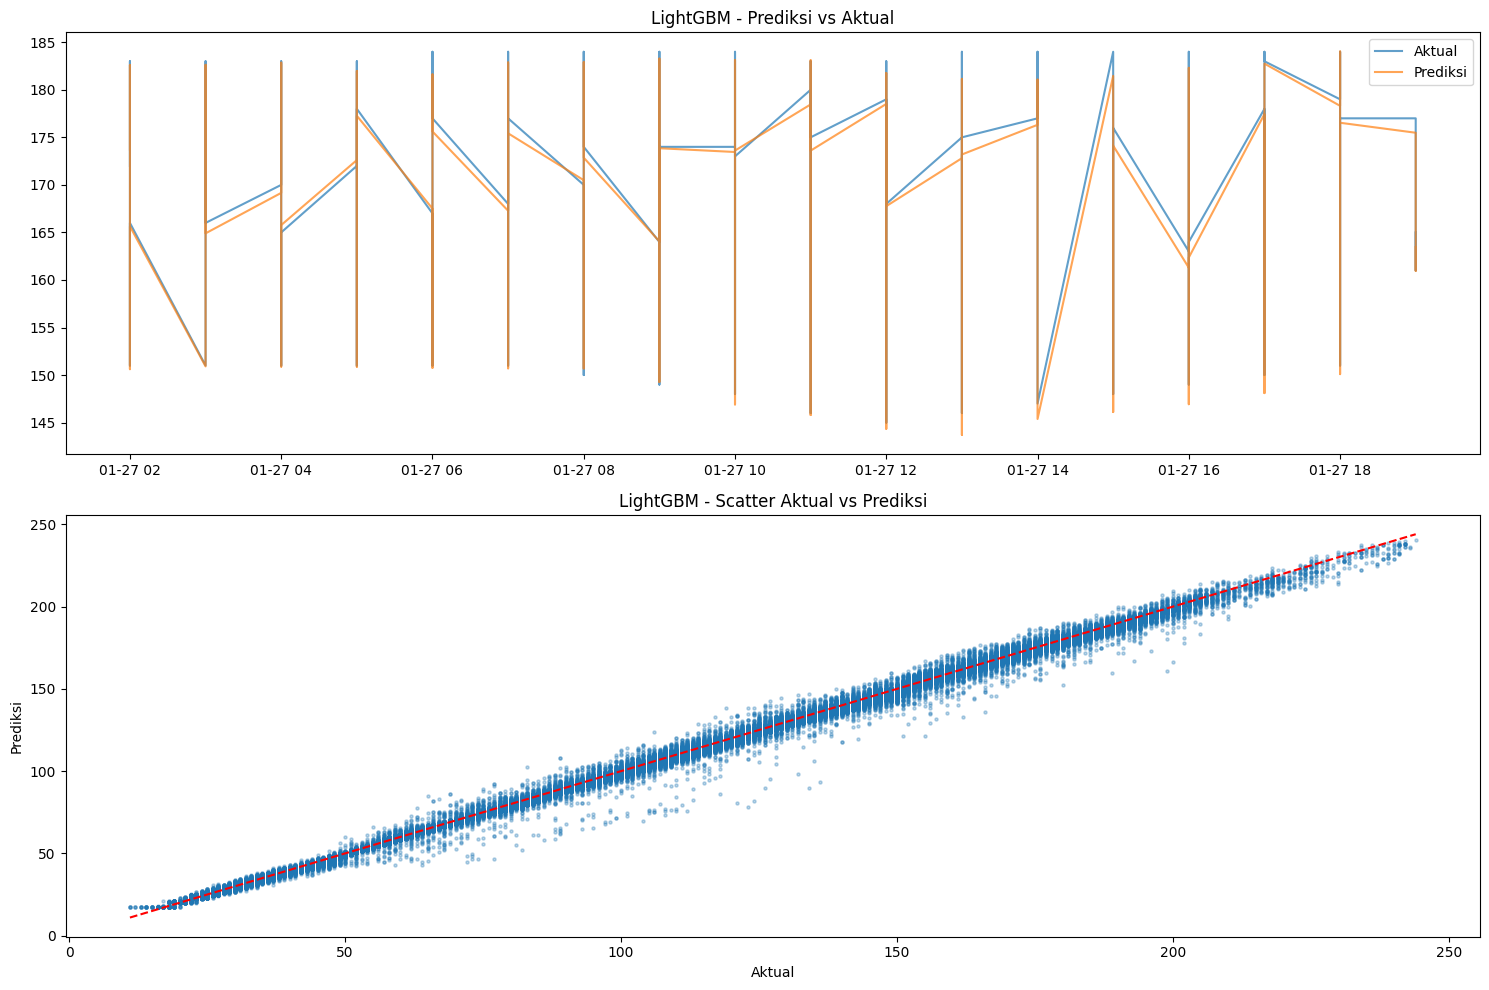

Plot disimpan ke results/plots/lightgbm_prediction.png
Model disimpan ke models/lightgbm_model.pkl


In [4]:
import lightgbm as lgb

# === Validation split: 10% terakhir dari train ===
val_size  = int(len(X_train_scaled) * 0.1)
X_tr  = X_train_scaled.iloc[:-val_size]
X_val = X_train_scaled.iloc[-val_size:]
y_tr  = y_train.iloc[:-val_size]
y_val = y_train.iloc[-val_size:]

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test_scaled.shape}")

# === Training LightGBM dengan early stopping ===
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\nBest iteration : {lgb_model.best_iteration_}")

# === Prediksi & Evaluasi ===
y_pred_lgb = lgb_model.predict(X_test_scaled)
# Evaluasi LightGBM pada subset yang sama dengan baseline (common_mask) — apple-to-apple
metrics_list.append(evaluate(y_eval, y_pred_lgb[common_mask], 'LightGBM'))

plot_predictions(df_test['datetime'].values[common_mask], y_eval, y_pred_lgb[common_mask], 'LightGBM')

# === Simpan model ===
os.makedirs('models', exist_ok=True)
joblib.dump(lgb_model, 'models/lightgbm_model.pkl')
print("Model disimpan ke models/lightgbm_model.pkl")

### 8.4 Export Model, Artifacts, dan Metrics

In [5]:
all_metrics = pd.DataFrame(metrics_list)
all_metrics.to_csv('results/metrics_comparison.csv', index=False)

print('=== Perbandingan Metrik Semua Model ===')
print(all_metrics.to_string(index=False))

print('\nArtifak tersimpan:')
print('  results/metrics_comparison.csv')
print('  models/lightgbm_model.pkl')

=== Perbandingan Metrik Semua Model ===
                      Model      MAE      RMSE       R2      MAPE
             Baseline Naive 1.251841  2.789903 0.996482  1.369496
Baseline Rolling Mean (24h) 8.593087 12.403936 0.930463 10.044196
                   LightGBM 1.133910  1.767104 0.998589  1.291379

Artifak tersimpan:
  results/metrics_comparison.csv
  models/lightgbm_model.pkl


### 8.5 Visualisasi Perbandingan Metrik

C:\Users\faizn\AppData\Local\Temp\ipykernel_3448\3231693835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\faizn\AppData\Local\Temp\ipykernel_3448\3231693835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\faizn\AppData\Local\Temp\ipykernel_3448\3231693835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\faizn\A

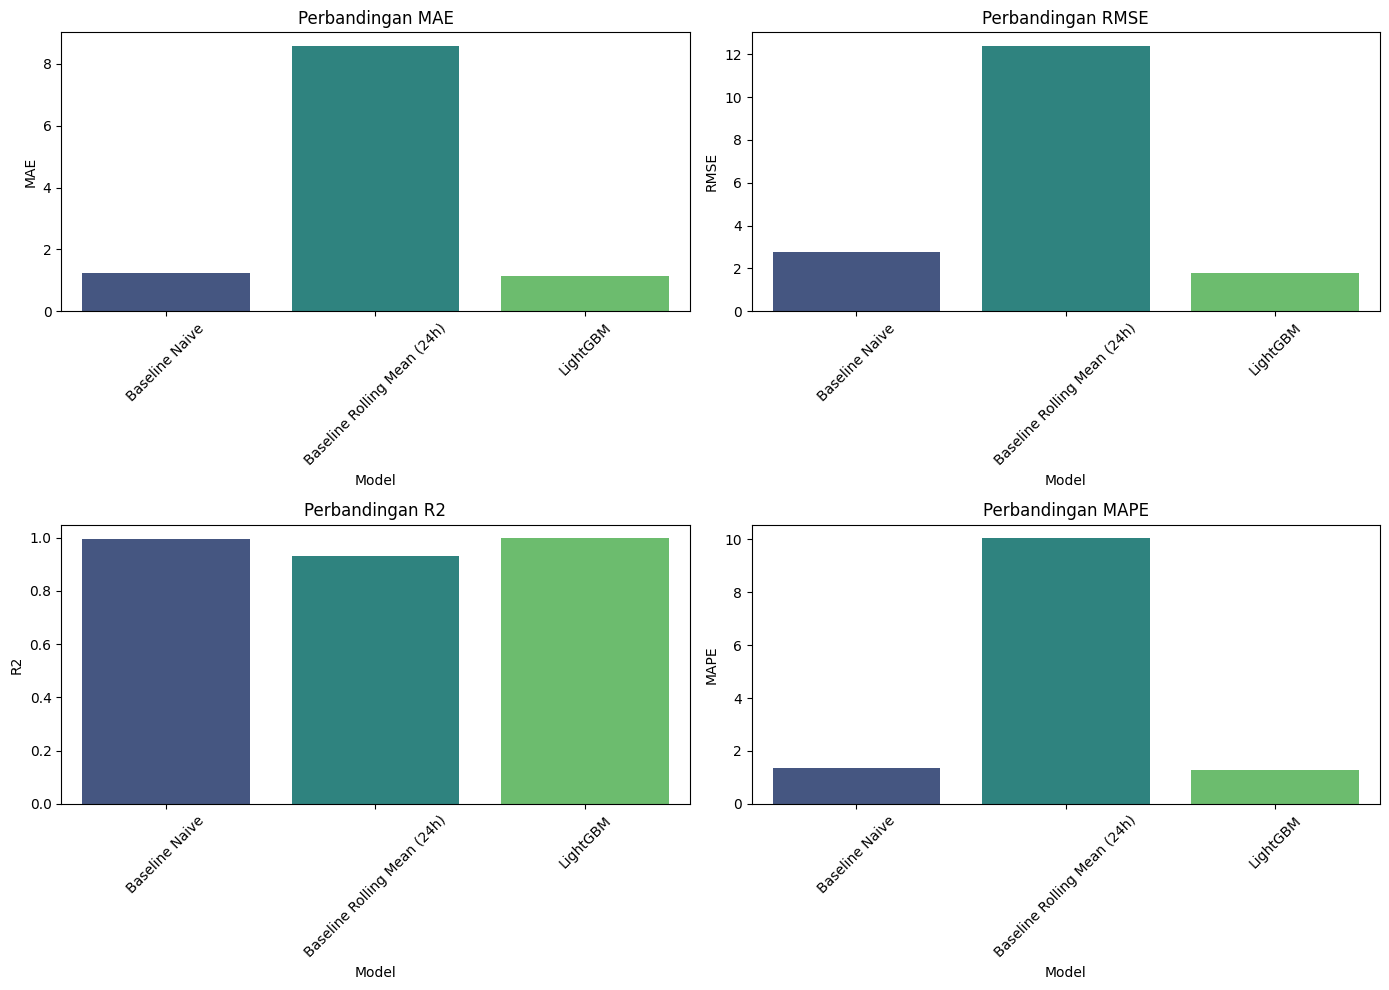

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_plot = ['MAE', 'RMSE', 'R2', 'MAPE']

for ax, metric in zip(axes.flat, metrics_plot):
    sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'Perbandingan {metric}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/plots/metrics_comparison_bar.png', dpi=120)
plt.show()

### 8.6 Interpretasi Kualitatif dan Kesimpulan

#### Mengapa LightGBM sebagai Model Utama?

Data AQI Bangladesh ini memiliki karakteristik yang sangat cocok untuk gradient boosting:

| Karakteristik Data | Implikasi untuk Model |
|---|---|
| 98 fitur tabular yang sudah direkayasa | LightGBM unggul pada tabular data vs neural network |
| Lag & rolling sudah eksplisit sebagai fitur | Model sequence tidak punya "rahasia" tambahan dari raw sequence |
| Dataset 1M+ baris | LightGBM histogram-based: 3–10x lebih cepat dari XGBoost |
| 30+ kota dengan pola berbeda (`city_encoded`) | Tree bisa split per kota secara natural |
| Distribusi polutan right-skewed | Tree splits robust terhadap skewness, tidak perlu normalisasi khusus |

#### Mengapa Baseline Naive Kompetitif di MAE?

AQI per jam bersifat sangat persisten (lag-1 autocorrelation per kota ≈ 0.97–0.99, diverifikasi di notebook 06), sehingga prediksi sederhana (`y[t] = y[t-1]`) sudah memberikan MAE yang kecil. Namun **LightGBM unggul signifikan di RMSE dan R²** — metrik yang lebih relevan untuk sistem early warning karena menghukum error ekstrem (spike AQI) lebih berat.

#### Catatan Metodologi

- **Train-Test Split**: Time-aware (80% awal = train, 20% akhir = test) — tidak ada data leakage temporal
- **Scaler**: RobustScaler di-fit hanya pada train set, lalu ditransformasi ke test
- **Early stopping**: Mencegah overfitting secara otomatis (monitoring val metric)

### 8.7 Validasi Anti-Leakage

In [7]:
assert df_train['datetime'].max() < df_test['datetime'].min(), \
    'Data leakage! Train dan test overlap secara waktu!'
print('Validasi Anti-Leakage Passed:')
print(f'  Train max : {df_train["datetime"].max()}')
print(f'  Test  min : {df_test["datetime"].min()}')

Validasi Anti-Leakage Passed:
  Train max : 2025-01-27 01:00:00
  Test  min : 2025-01-27 02:00:00
